In [1]:
import numpy as np
import networkx as nx
from grakel import GraphKernel
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.utils import to_networkx

In [2]:
import networkx as nx
from torch_geometric.datasets import TUDataset

# Specify the name of the dataset you want to load
dataset_name = 'ENZYMES'  # Example dataset name

# Load the dataset
dataset = TUDataset(root='data/TUDataset', name=dataset_name)

# Get the first graph from the dataset
data = dataset[0]

# Convert PyG data to NetworkX graph
G1 = nx.Graph()
G1.add_edges_from(data.edge_index.T.numpy())

# Compute edge weights (e.g., using edge betweenness centrality)
edge_weights = nx.edge_betweenness_centrality(G1)


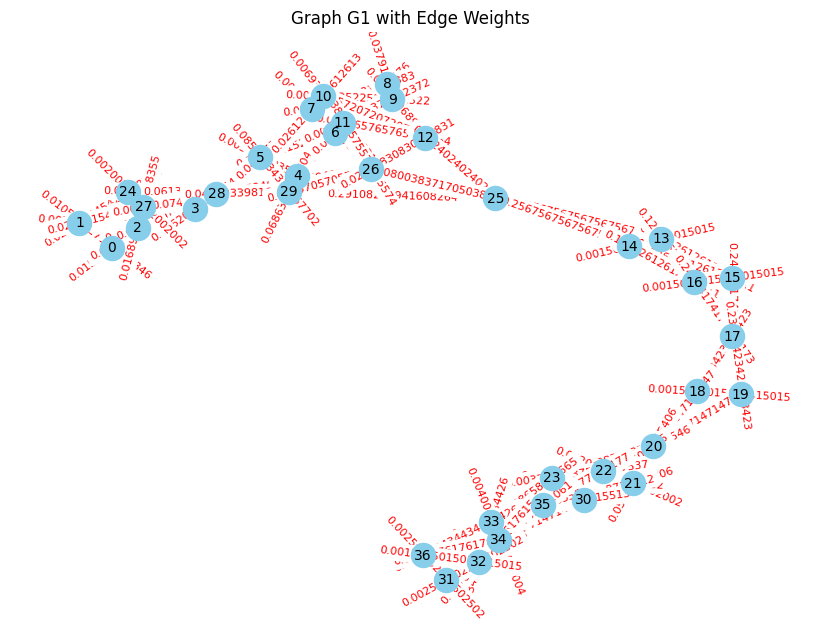

In [3]:
# Plot the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G1)  # positions for all nodes
nx.draw(G1, pos, with_labels=True, node_size=300, node_color="skyblue", font_size=10)
nx.draw_networkx_edge_labels(G1, pos, edge_labels=edge_weights, font_color='red', font_size=8)
plt.title("Graph G1 with Edge Weights")
plt.show()

In [4]:

# Get the first graph from the dataset
data2 = dataset[1]

# Convert PyG data to NetworkX graph
G2 = nx.Graph()
G2.add_edges_from(data2.edge_index.T.numpy())

# Compute edge weights (e.g., using edge betweenness centrality)
edge_weights2 = nx.edge_betweenness_centrality(G2)


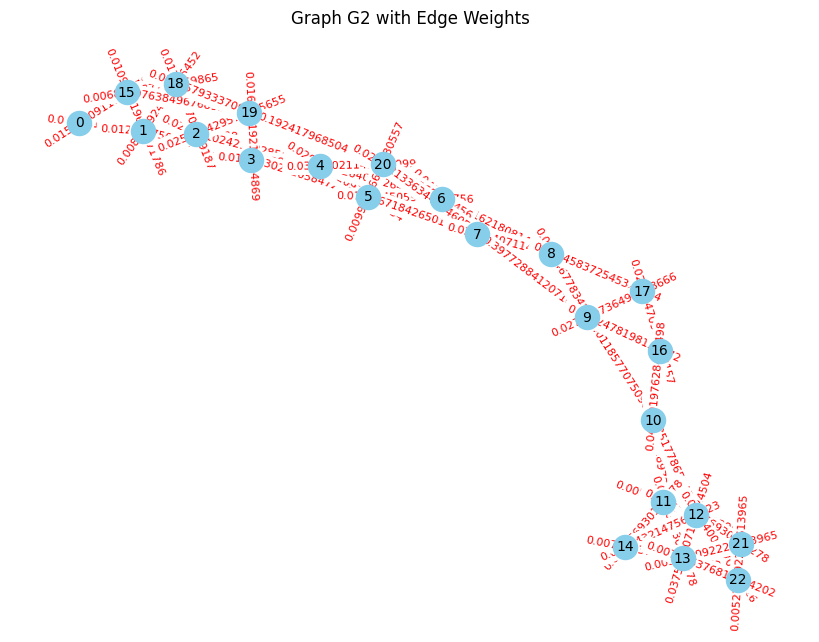

In [5]:
# Plot the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G2)  # positions for all nodes
nx.draw(G2, pos, with_labels=True, node_size=300, node_color="skyblue", font_size=10)
nx.draw_networkx_edge_labels(G2, pos, edge_labels=edge_weights2, font_color='red', font_size=8)
plt.title("Graph G2 with Edge Weights")
plt.show()

There are two main ways to look at communication efficiency in graphs:

1. Network Efficiency (Global Efficiency): This refers to how well information travels across the entire network.

A highly efficient network can get information from any one point to another quickly and easily.

In graph theory, this is often measured by the average shortest path length between all nodes in the network.

The smaller the average distance, the more efficient the communication.

2. Local Efficiency: This looks at how well information flows between neighboring nodes

(nodes that are directly connected by an edge). A network with high local efficiency can easily reroute

information if one connection is disrupted.

Aspects that influence communication efficiency in graphs:

Number of Edges: Generally, more edges (connections) allow for more pathways for information to travel, potentially increasing efficiency.

Edge Weights: If edges have weights associated with them (representing factors like distance or transmission speed), these weights can affect how efficiently information travels along that path.

Network Diameter: The diameter of a network is the greatest distance between any two nodes. A smaller diameter indicates that information can travel across the network more quickly.

## Communication efficiency in cosine similarity kernel

If two nodes have a high cosine similarity value, it means they are connected to similar sets of nodes, indicating a potential efficient path for communication or information exchange between them. Conversely, a low cosine similarity suggests less similarity in their connectivity patterns, potentially hindering efficient communication between those nodes.

In [6]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def cosine_similarity_kernel(graph):
    # Convert the graph to an adjacency matrix
    adjacency_matrix = nx.to_numpy_matrix(graph)

    # Handle NaN values by setting them to zero
    adjacency_matrix = np.nan_to_num(adjacency_matrix)

    # Compute the cosine similarity between nodes
    cosine_similarity_matrix = np.zeros(adjacency_matrix.shape)

    for i in range(adjacency_matrix.shape[0]):
        for j in range(adjacency_matrix.shape[0]):
            if i == j:
                cosine_similarity_matrix[i, j] = 1.0
            else:
                dot_product = np.dot(adjacency_matrix[i], adjacency_matrix[j].T)
                norm_i = np.linalg.norm(adjacency_matrix[i])
                norm_j = np.linalg.norm(adjacency_matrix[j])

                cosine_similarity_matrix[i, j] = dot_product / (norm_i * norm_j)

    return cosine_similarity_matrix


The resulting matrix provides insights into how effectively information can flow between different atoms (nodes) based on their connectivity patterns (edges)

Each cell in the heatmap represents the cosine similarity between the connectivity patterns of two nodes in the graph. A high cosine similarity value (brighter color) indicates that the connectivity patterns of the corresponding nodes are highly similar, suggesting efficient communication paths between them. Conversely, a low cosine similarity value (darker color) indicates less similarity in connectivity patterns, potentially indicating less efficient communication paths between the corresponding nodes.

the white cells along the diagonal signify the perfect communication efficiency of each node with itself, which is a fundamental property

/var/folders/j6/hm4_f_1j3mn765k399w02gx00000gn/T/ipykernel_7402/4129159164.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cosine_similarity_matrix[i, j] = dot_product / (norm_i * norm_j)


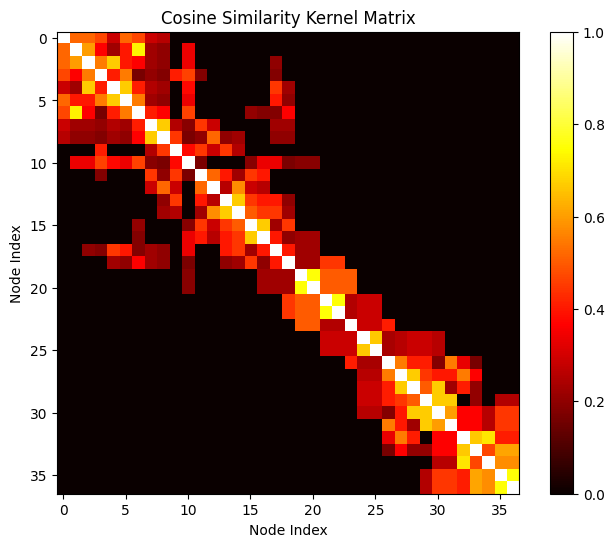

In [7]:


# Compute the cosine similarity kernel
cosine_similarity_matrix = cosine_similarity_kernel(G1)

# Plot the cosine similarity matrix
plt.figure(figsize=(8, 6))
plt.imshow(cosine_similarity_matrix, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('Cosine Similarity Kernel Matrix')
plt.xlabel('Node Index')
plt.ylabel('Node Index')
plt.show()
